<a href="https://colab.research.google.com/github/karinenoronha/world_cup/blob/main/worldCup_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Quais fatores estão mais associados ao sucesso de uma seleção em Copas do Mundo?**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_matches = pd.read_csv("matches_1930_2022.csv")
df_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   home_team                        964 non-null    object 
 1   away_team                        964 non-null    object 
 2   home_score                       964 non-null    int64  
 3   home_xg                          128 non-null    float64
 4   home_penalty                     35 non-null     float64
 5   away_score                       964 non-null    int64  
 6   away_xg                          128 non-null    float64
 7   away_penalty                     35 non-null     float64
 8   home_manager                     964 non-null    object 
 9   home_captain                     644 non-null    object 
 10  away_manager                     964 non-null    object 
 11  away_captain                     644 non-null    object 
 12  Attendance            

In [4]:
df_matches.head()

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [5]:
df_matches.shape

(964, 44)

In [6]:
df_matches.isnull().sum()

,0
home_team,0
away_team,0
home_score,0
home_xg,836
home_penalty,929
away_score,0
away_xg,836
away_penalty,929
home_manager,0
home_captain,320


In [7]:
#Romovendo colunas com mais de 50% de nulos

limite = len(df_matches) * 0.5
df_matches_clean = df_matches.drop(columns=df_matches.columns[df_matches.isna().sum() > limite])

In [8]:
df_matches_clean.isnull().sum()

,0
home_team,0
away_team,0
home_score,0
away_score,0
home_manager,0
home_captain,320
away_manager,0
away_captain,320
Attendance,0
Venue,0


In [9]:
df_matches_clean['Date'] = pd.to_datetime(df_matches_clean['Date'])
df_matches_clean['Date'].head()

df_matches_clean['Year'] = df_matches_clean['Date'].dt.year

Quais Seleções jogaram mais partidas?

In [10]:
home =df_matches_clean['home_team']
away = df_matches_clean['away_team']

all_teams = pd.concat([home,away])
all_teams.value_counts()

,count
Brazil,114
Argentina,88
Italy,83
England,74
France,73
...,...
Zaire,3
Cuba,3
Kuwait,3
Israel,3


<Axes: >

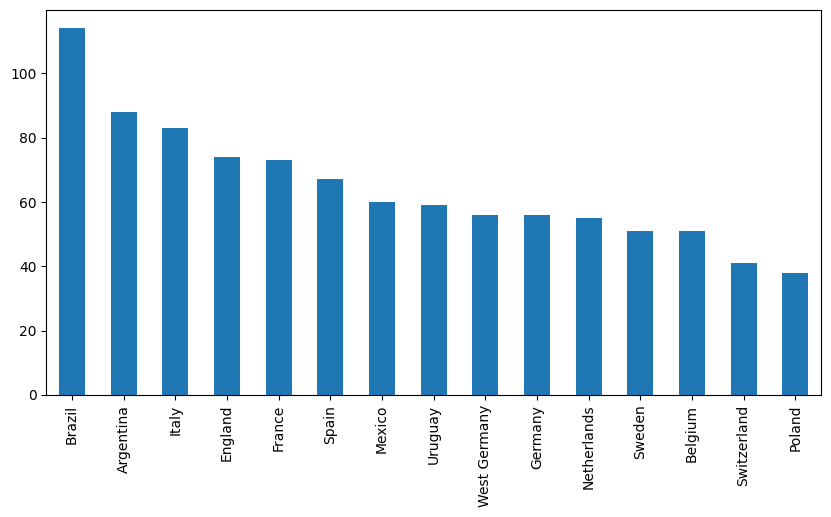

In [11]:
# Fazendo grafico de barras

all_teams.value_counts().head(15).plot(kind='bar', figsize=(10,5))

Brazil é a seleção que possui mais jogos nas Copas do Mundo. Vale ressaltar que Argentina tem mais jogos que a Italia, mesmo que tenha menos titulos.

# EVOLUÇÃO DE GOLS

In [12]:
df_matches_clean['total_gol'] = df_matches_clean['home_score'] + df_matches_clean['away_score']


In [13]:
gols_por_ano = df_matches_clean.groupby(df_matches_clean['Date'].dt.year)['total_gol'].mean()


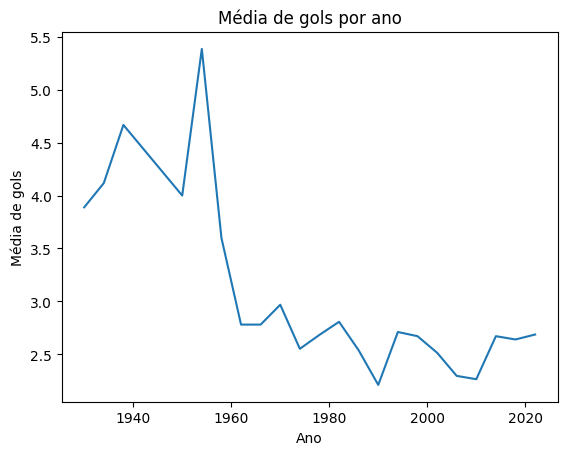

In [14]:
sns.lineplot(x=gols_por_ano.index, y=gols_por_ano.values)
plt.title('Média de gols por ano')
plt.xlabel('Ano')
plt.ylabel('Média de gols')

plt.show()

Insight : O futebol moderno representa menos gols que em decadas passadas

Quais estados receberam mais jogos?

In [15]:
df_matches_clean['Venue'].value_counts().head(15)

,count
Venue,
"Estadio Azteca, Mexico City",19
"Jalisco, Guadalajara",14
"Nou Camp - Estadio Leï¿½n, Leon",11
"Nacional, Santiago De Chile",10
"Lusail Iconic Stadium, Lusail",10
"Estadio Centenario, Montevideo",10
"Al Bayt Stadium, Al Khor",9
"Wembley Stadium, London",9
"El Monumental - Estadio Monumental Antonio Vespuci, Buenos Aires",9


Existe vantagem em jogar em casa?

In [16]:
df_matches_clean['home_win'] = df_matches_clean['home_score'] > df_matches_clean['away_score']
df_matches_clean['home_win'].value_counts()

,count
home_win,
True,532
False,432


In [17]:
df_matches_clean['home_win'].mean()

np.float64(0.5518672199170125)

Insight : Times mandantes venceram em  532 (55.18%) das vezes que jogaram em casa

Qual a seleção tem o melhor aproveitamento ?

In [18]:
home = df_matches_clean[["home_team", "home_score", "away_score"]].copy()
home.columns = ["team", "goals_for", "goals_against"]

away = df_matches_clean[["away_team", "away_score", "home_score"]].copy()
away.columns = ["team", "goals_for", "goals_against"]

teams = pd.concat([home, away])

In [19]:
teams['goal_difference'] = teams['goals_for'] - teams['goals_against']

team_performance = teams.groupby('team').agg(
    total_goals_for=('goals_for', 'sum'),
    total_goals_against=('goals_against', 'sum'),
    total_goal_difference=('goal_difference', 'sum'),
    matches_played=('team', 'count')
)

print(team_performance.sort_values(by='total_goal_difference', ascending=False).head(10))

              total_goals_for  total_goals_against  total_goal_difference  \
team                                                                        
Brazil                    237                  108                    129   
Germany                   126                   67                     59   
France                    136                   85                     51   
Italy                     128                   77                     51   
Argentina                 152                  101                     51   
Netherlands                96                   52                     44   
West Germany              106                   63                     43   
England                   104                   68                     36   
Spain                     108                   75                     33   
Hungary                    87                   57                     30   

              matches_played  
team                          
Brazil       

In [20]:
df_matches_clean["winner"] = np.where(
    df_matches_clean["home_score"] > df_matches_clean["away_score"],
    df_matches_clean["home_team"],
    np.where(
        df_matches_clean["home_score"] < df_matches_clean["away_score"],
       df_matches_clean["away_team"],
        "Draw"
    )
)

In [21]:
#Aproveitamento

stats = teams.groupby("team").agg(
    jogos=("team", "count"),
    gols_feitos=("goals_for", "sum"),
    gols_sofridos=("goals_against", "sum")
)

wins = df_matches_clean["winner"].value_counts()

stats["vitorias"] = stats.index.map(wins).fillna(0)
stats["aproveitamento"] = stats["vitorias"] / stats["jogos"]

In [22]:
stats.sort_values("aproveitamento", ascending=False).head(10)

,jogos,gols_feitos,gols_sofridos,vitorias,aproveitamento
team,,,,,
Brazil,114,237,108,76.0,0.666667
Germany,56,126,67,37.0,0.660714
West Germany,56,106,63,31.0,0.553571
Netherlands,55,96,52,30.0,0.545455
Italy,83,128,77,45.0,0.542169
France,73,136,85,39.0,0.534247
Argentina,88,152,101,47.0,0.534091
FR Yugoslavia,4,5,4,2.0,0.500000
Türkiye,10,20,17,5.0,0.500000


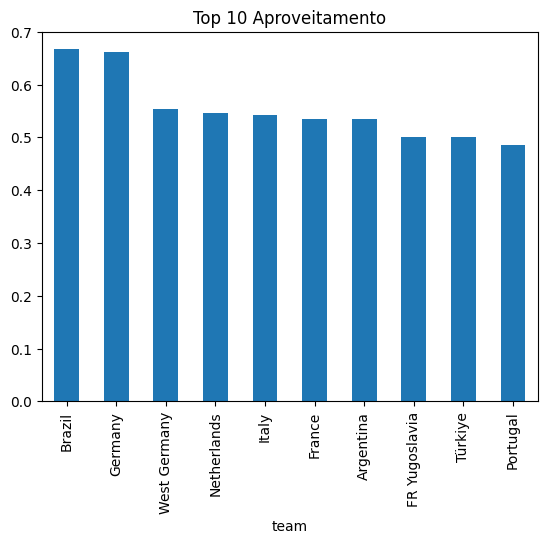

In [23]:
stats.sort_values("aproveitamento", ascending=False).head(10)["aproveitamento"].plot(kind="bar")
plt.title("Top 10 Aproveitamento")
plt.show()

seleções por decadas

In [24]:
df_matches_clean["decade"] = (df_matches_clean["Year"] // 10) * 10

In [25]:
# Calculate team performance by decade
team_performance_by_decade = []

for index, row in df_matches_clean.iterrows():
    decade = row['decade']
    home_team = row['home_team']
    away_team = row['away_team']
    winner = row['winner']

    # Home team's perspective
    team_performance_by_decade.append({
        'team': home_team,
        'decade': decade,
        'games_played': 1,
        'wins': 1 if winner == home_team else 0
    })

    # Away team's perspective
    team_performance_by_decade.append({
        'team': away_team,
        'decade': decade,
        'games_played': 1,
        'wins': 1 if winner == away_team else 0
    })

df_team_decade = pd.DataFrame(team_performance_by_decade)

# Aggregate to get total games and wins per team per decade
decade_stats = df_team_decade.groupby(['team', 'decade']).agg(
    total_games=('games_played', 'sum'),
    total_wins=('wins', 'sum')
).reset_index()

# Calculate win rate
decade_stats['win_rate'] = decade_stats['total_wins'] / decade_stats['total_games']

# Display top teams by win rate for each decade
for decade in sorted(decade_stats['decade'].unique()):
    print(f"\n--- Top 5 Teams in {decade}s ---")
    top_teams_decade = decade_stats[decade_stats['decade'] == decade].sort_values(
        by='win_rate', ascending=False
    ).head(5)
    print(top_teams_decade)



--- Top 5 Teams in 1930s ---
           team  decade  total_games  total_wins  win_rate
288     Uruguay    1930            4           4  1.000000
142       Italy    1930            9           8  0.888889
3     Argentina    1930            6           4  0.666667
129     Hungary    1930            6           4  0.666667
304  Yugoslavia    1930            3           2  0.666667

--- Top 5 Teams in 1950s ---
        team  decade  total_games  total_wins  win_rate
115  Germany    1950            6           5  0.833333
34    Brazil    1950           15          10  0.666667
289  Uruguay    1950            9           6  0.666667
106   France    1950            8           5  0.625000
130  Hungary    1950            9           5  0.555556

--- Top 5 Teams in 1960s ---
             team  decade  total_games  total_wins  win_rate
210      Portugal    1960            6           5  0.833333
35         Brazil    1960            9           6  0.666667
97        England    1960           1

In [26]:
# Brasil

brasil = df_matches_clean[
    (df_matches_clean["home_team"] == "Brazil") |
    (df_matches_clean["away_team"] == "Brazil")
].copy()

In [27]:
def result(row):
    if row["home_team"] == "Brazil":
        if row["home_score"] > row["away_score"]:
            return "Win"
        elif row["home_score"] < row["away_score"]:
            return "Loss"
        else:
            return "Draw"
    else:
        if row["away_score"] > row["home_score"]:
            return "Win"
        elif row["away_score"] < row["home_score"]:
            return "Loss"
        else:
            return "Draw"

brasil["result"] = brasil.apply(result, axis=1)

/tmp/ipykernel_3898/3053152096.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='win_rate', y='team', data=top_teams_decade, ax=ax, palette='viridis')
/tmp/ipykernel_3898/3053152096.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='win_rate', y='team', data=top_teams_decade, ax=ax, palette='viridis')
/tmp/ipykernel_3898/3053152096.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='win_rate', y='team', data=top_teams_decade, ax=ax, palette='viridis')
/tmp/ipykernel_3898/3053152096.py:11: FutureWarning: 

Passing `palette` wit

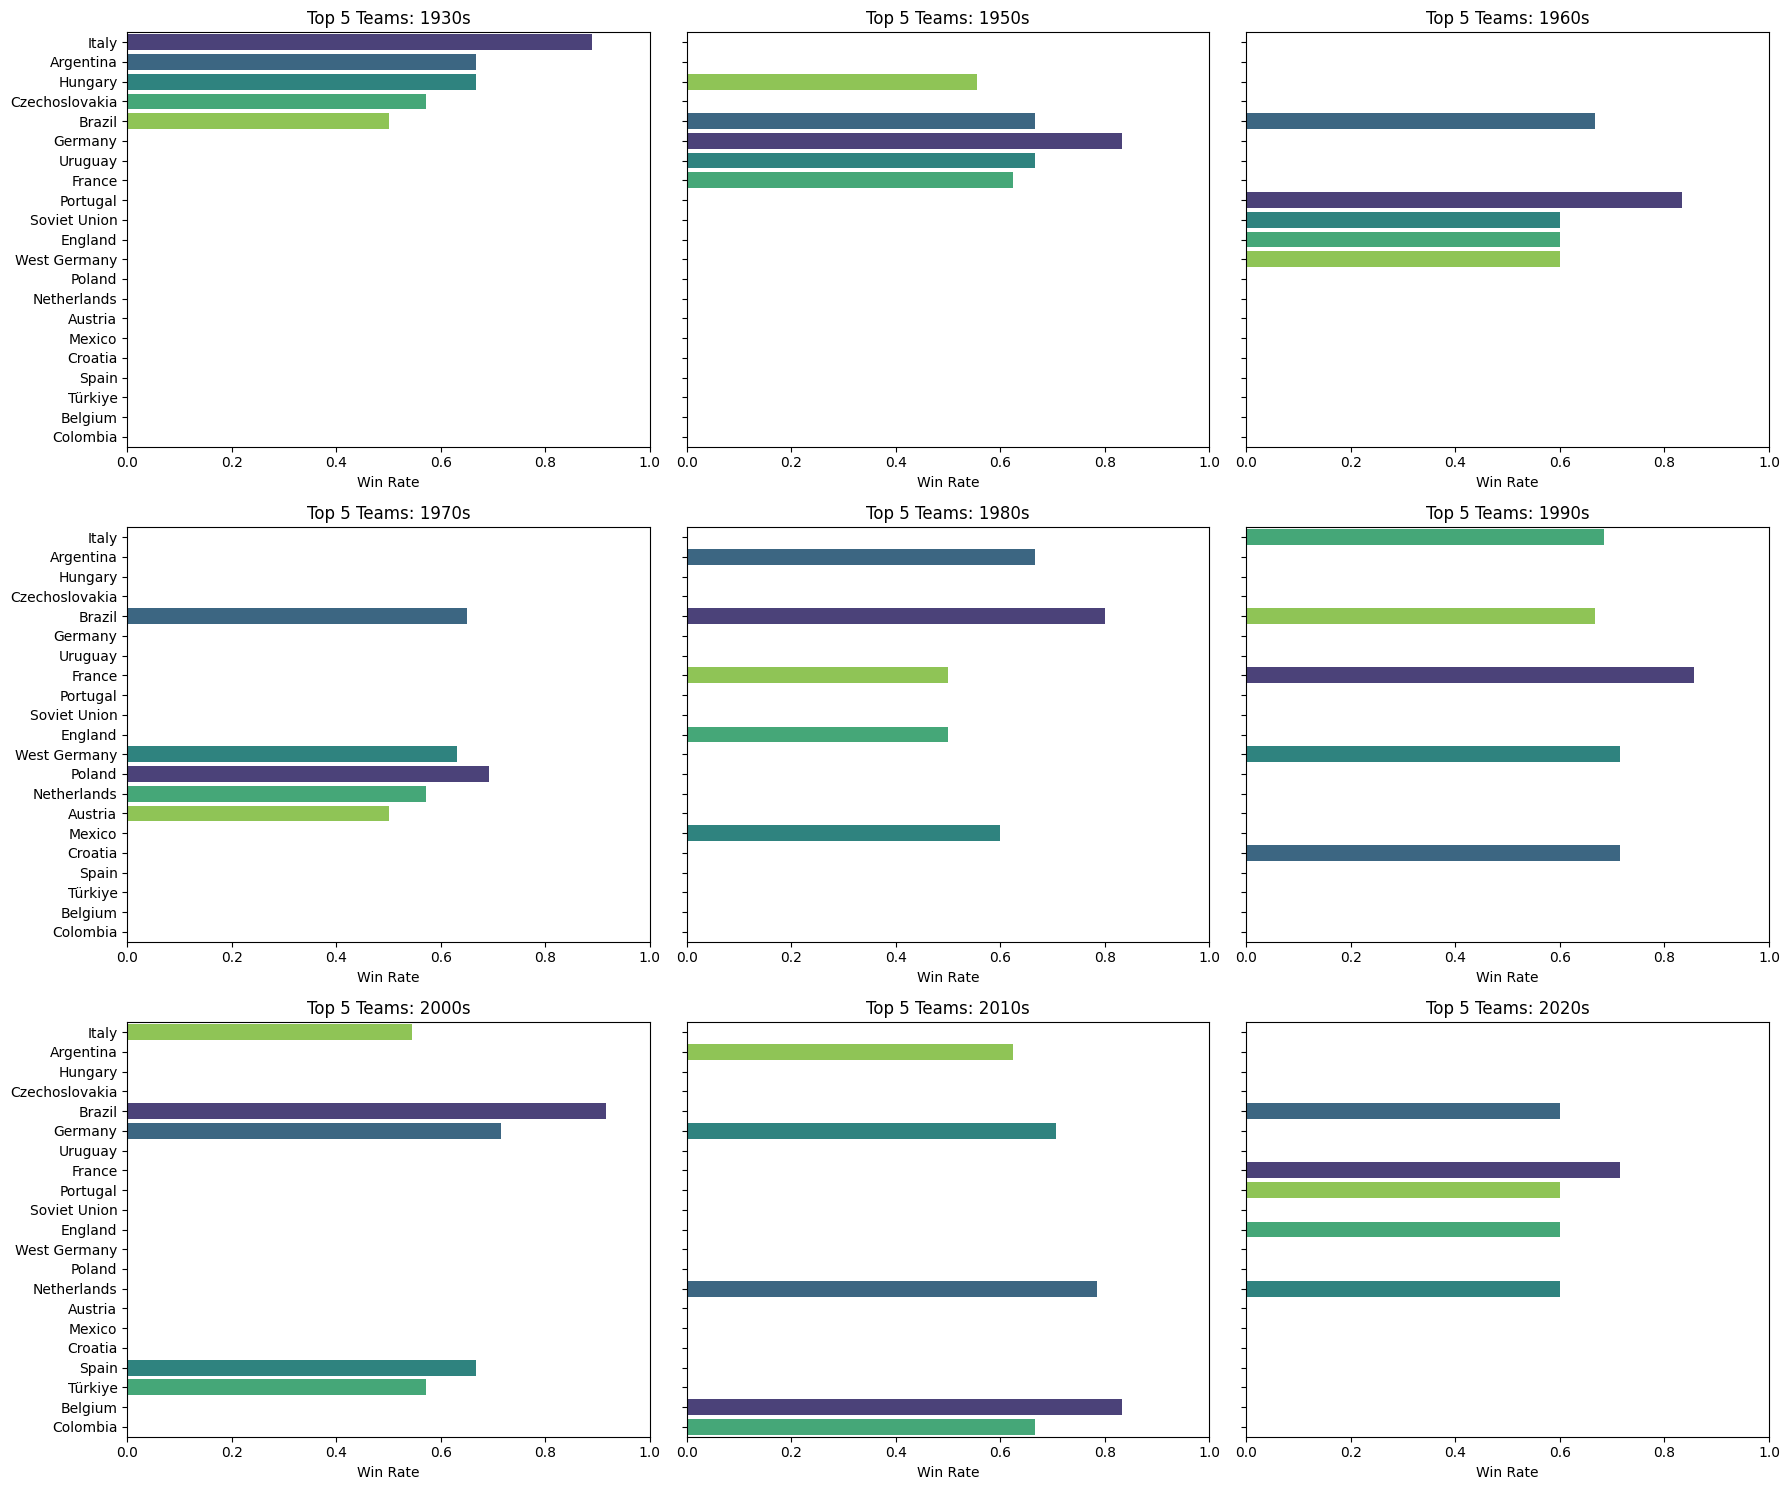

In [28]:
# Visualize top teams by win rate per decade
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15), sharey=True)
axes = axes.flatten()

for i, decade in enumerate(sorted(decade_stats['decade'].unique())):
    ax = axes[i]
    top_teams_decade = decade_stats[
        (decade_stats['decade'] == decade) & (decade_stats['total_games'] >= 5) # Filter for teams with at least 5 games in the decade
    ].sort_values(by='win_rate', ascending=False).head(5)

    sns.barplot(x='win_rate', y='team', data=top_teams_decade, ax=ax, palette='viridis')
    ax.set_title(f'Top 5 Teams: {decade}s')
    ax.set_xlabel('Win Rate')
    ax.set_ylabel('')
    ax.set_xlim(0, 1) # Win rate is between 0 and 1

plt.tight_layout()
plt.show()


### Análise do Brasil por década

Vamos agora aprofundar na performance do Brasil ao longo das décadas.

In [29]:
brasil["decade"] = (brasil["Year"] // 10) * 10

evolucao = brasil.groupby("decade").agg(
    jogos=("result", "count"),
    vitorias=("result", lambda x: (x == "Win").sum())
)

evolucao["win_rate"] = evolucao["vitorias"] / evolucao["jogos"]

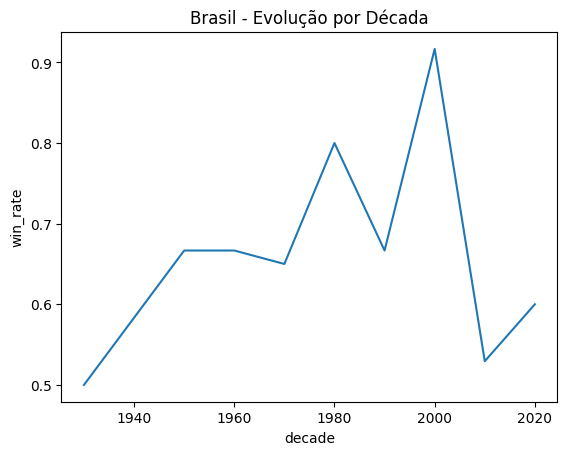

In [30]:
sns.lineplot(data=evolucao, x=evolucao.index, y="win_rate")
plt.title("Brasil - Evolução por Década")
plt.show()

Copa mais ofensiva

In [31]:
mais_ofensivas = df_matches_clean.groupby("Year")["total_gol"].sum().sort_values(ascending=False)
mais_ofensivas.head(10)

,total_gol
Year,
2022,172
1998,171
2014,171
2018,169
2002,161
2006,147
1982,146
2010,145
1994,141


In [32]:
df_world = pd.read_csv("world_cup.csv")
df_world.head()

,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64
3,2010,South Africa,32,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",3178856,49670,64
4,2006,Germany,32,Italy,France,Miroslav Klose - 5,3352605,52384,64


In [35]:
from google.colab import files
files.download("matches_1930_2022.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>